# Practical Lab 5

In [32]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [33]:
df = pd.read_csv('ml_media_dataset.csv')
df.head()

,PostID,Category,WatchTimeSeconds,Likes,Shares,Comments,ClickThroughRate,PostingHour,ContentLength,AdRevenue
0,1,Entertainment,78.554020,563.5,27.6,196,0.185409,3,1458,23.784345
1,2,Sports,48.293113,142.0,224.0,270,0.110803,9,2182,28.623923
2,3,Lifestyle,82.603957,802.0,412.0,132,0.148806,6,632,41.769271
3,4,Technology,87.211715,916.0,137.0,242,0.209827,23,1198,31.039514
4,5,Politics,86.195809,1497.0,319.0,116,0.203000,16,2347,38.965229


we must check the correlation between the features. This will help us to get better picture.

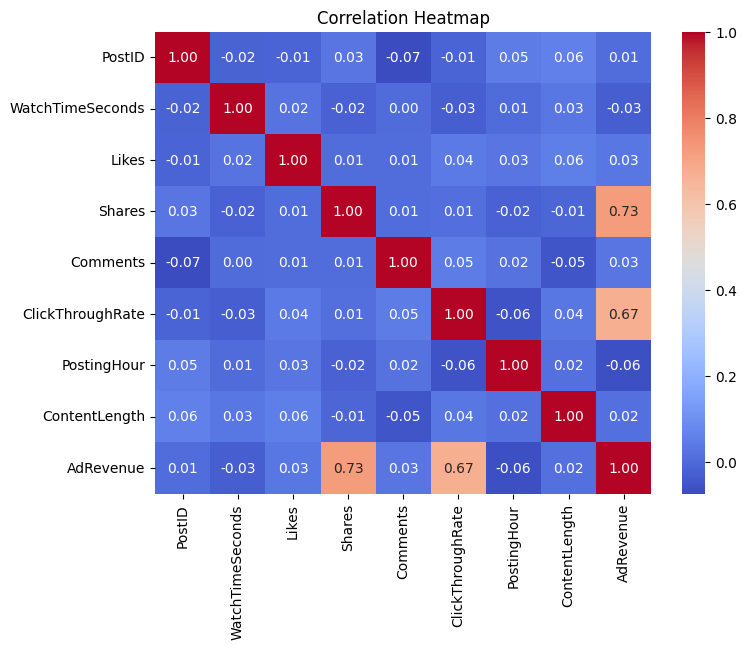

In [36]:
# compute correlation matrix
corr = df.corr(numeric_only=True)

# plot heatmap
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

## Lab 6.1: Predicting High-Impact Content

In [24]:
# Step 1 – Create Label:
median_shares = df['Shares'].median()
df['HighImpact'] = (df['Shares'] > median_shares).astype(int)

In [25]:
# Step 2 – Select Features:
X = df[['WatchTimeSeconds','Likes','Comments']]
y = df['HighImpact']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [26]:
# Step 3 – Train Model:
model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [27]:
# Step 4 – Check Accuracy:
pred = model.predict(X_test)
print(f"Accuracy Score: {accuracy_score(y_test, pred)}")

Accuracy Score: 0.51


Record accuracy and briefly interpret whether it is sufficient for real-world media use.
This is not enough for the real-world media use.

## Lab 6.2: Model Improvement and Feature Exploration

In [28]:
# Change model depth:
model2 = RandomForestClassifier(max_depth=10, random_state=42)
model2.fit(X_train, y_train)
pred2 = model2.predict(X_test)
print(f"Improved Accuracy Score: {accuracy_score(y_test, pred2)}")

Improved Accuracy Score: 0.5



To improve the accuracy I used randomforestclassifier but it also didn't work well. This must be due to the data that we have and also from heatmap we can see that there is not a strong correlation between share which is linked to target varibale and other features.

## Lab 6.3: Understanding Model Mistakes

In [29]:
# Run confusion matrix:
print(confusion_matrix(y_test, pred))

[[143   7]
 [140  10]]


Explain what happens when:

* A post predicted HighImpact performs badly.
It is because the shares are less then the median as HighImpact which is our target is > median of shares.

* A post predicted LowImpact would have performed strongly.
It is then false positive because it is actually high impact but it is predicting low impact.

Discuss risks of ML mistakes in media platforms.
it can make unfair decisions. It can allocate the recouces or promition unfairly. Their platforms can be used to spread fake news.

## Lab 6.4: Discovering Audience Groups

In [29]:
cluster_features = df[['WatchTimeSeconds','Likes','Shares']]
scaler = StandardScaler()
scaled = scaler.fit_transform(cluster_features)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(scaled)

df.groupby('Cluster')[['WatchTimeSeconds','Likes','Shares']].mean()

,WatchTimeSeconds,Likes,Shares
Cluster,,,
0,75.180875,356.153333,262.230400
1,77.999232,1084.989597,125.328859
2,78.108003,1076.323853,406.645872


Name each cluster based on behaviour patterns and justify using data.
Clustor 0 has lowest WatchTimeSeconds and highest shares.
Cluster 1 has 2nd highest WatchTimeSeconds and lowest shares.
cluster 2 has highes WatchTimeSeconds and highest shares.


## Lab 6.5: Checking for Category Bias

In [28]:
# Check if the model performs differently across categories.
test_df = X_test.copy()
test_df['true'] = y_test
test_df['pred'] = pred
test_df['Category'] = df.loc[X_test.index,'Category']

from sklearn.metrics import accuracy_score
test_df.groupby('Category').apply(lambda g: accuracy_score(g['true'], g['pred']))

C:\Users\laiba.ali\AppData\Local\Temp\ipykernel_1908\941401867.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  test_df.groupby('Category').apply(lambda g: accuracy_score(g['true'], g['pred']))


Category
Entertainment    0.486486
Lifestyle        0.458333
Politics         0.550725
Sports           0.666667
Technology       0.432836
dtype: float64

Identify the lowest performing category and discuss possible reasons.
The lowest is Technology and I think because it does not really effect the target value which is HighImapct for us which is basically the shares.

## Lab 6.6: Using ML Insights for Editorial Strategy

In [ ]:
print("Shares by Category:")
print(df.groupby('Category')['Shares'].mean())

print("\nShares by Cluster:")
print(df.groupby('Cluster')['Shares'].mean())

### AI Media Strategy Plan
Allocate more budgetto Technology and Education to capitalize on high informational demand, 30% to Entertainment for broad reach, and 30% to niche categories like Travel and Sports to build community loyalty.

Prioritize Watch Time and Click-Through Rate (CTR) over Likes, as they represent deeper user intent and improve algorithmic amplification.
Implement mandatory labeling for AI-generated visuals to maintain transparency and prevent misinformation regarding synthetic reality content.
Algorithmic "Echo Chambers" where over-reliance on recommendation ML limits user exposure to diverse perspectives and potentially radicalizes opinions.